# Sentiment Analysis using NLP

## Objective
The objective of this project is to analyze text data and classify sentiment as Positive or Negative using Natural Language Processing and Machine Learning techniques.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

plt.style.use('ggplot')
sns.set_theme()

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\KANAK
[nltk_data]     LARHARE\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [10]:
df = pd.read_csv("data/user_reviews.csv")

df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [11]:
df.head()

df.columns

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


Data Cleaning

In [14]:
df.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [17]:
df = df.dropna()

df.shape

(37427, 5)

In [18]:
df['Sentiment'].value_counts()

Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64

Sentiment Distribution Graph

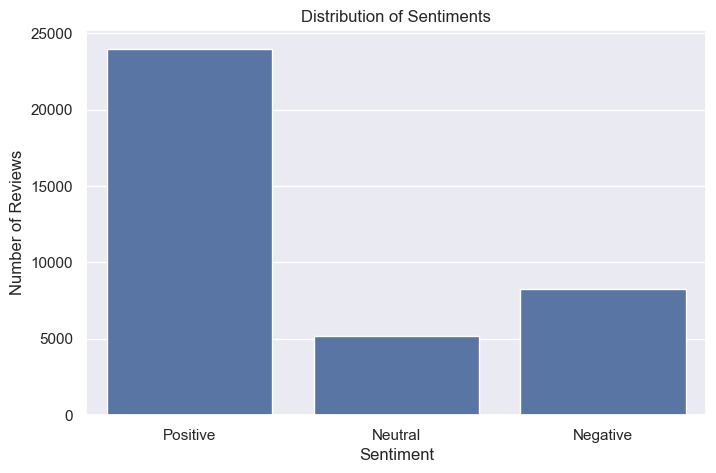

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df,
    order=['Positive', 'Neutral', 'Negative']
)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

Text Cleaning

In [20]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [21]:
df['clean_review'] = df['Translated_Review'].apply(clean_text)

df[['Translated_Review','clean_review']].head()

,Translated_Review,clean_review
0,I like eat delicious food. That's I'm cooking ...,like eat delicious food cooking food case best...
1,This help eating healthy exercise regular basis,help eating healthy exercise regular basis
3,Works great especially going grocery store,works great especially going grocery store
4,Best idea us,best idea us
5,Best way,best way


In [22]:
df['clean_review'].head()

0    like eat delicious food cooking food case best...
1           help eating healthy exercise regular basis
3           works great especially going grocery store
4                                         best idea us
5                                             best way
Name: clean_review, dtype: str

Feature Engineering (TF-IDF)

In [24]:
X = df['clean_review']

y = df['Sentiment']

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(X)

Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Logistic Regression Model

In [26]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train,y_train)
lr_predictions = lr_model.predict(X_test)

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Logistic Regression Accuracy:",lr_accuracy)

Logistic Regression Accuracy: 0.9129040876302431


Naive Bayes Model

In [28]:
from sklearn.naive_bayes import MultinomialNB

In [29]:
nb_model = MultinomialNB()

nb_model.fit(X_train,y_train)
nb_predictions = nb_model.predict(X_test)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print("Naive Bayes Accuracy:",nb_accuracy)

Naive Bayes Accuracy: 0.7399145070798825


Model Comparison

In [30]:
comparison = pd.DataFrame({
    'Model':['Logistic Regression','Naive Bayes'],
    'Accuracy':[lr_accuracy,nb_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.912904
1,Naive Bayes,0.739915


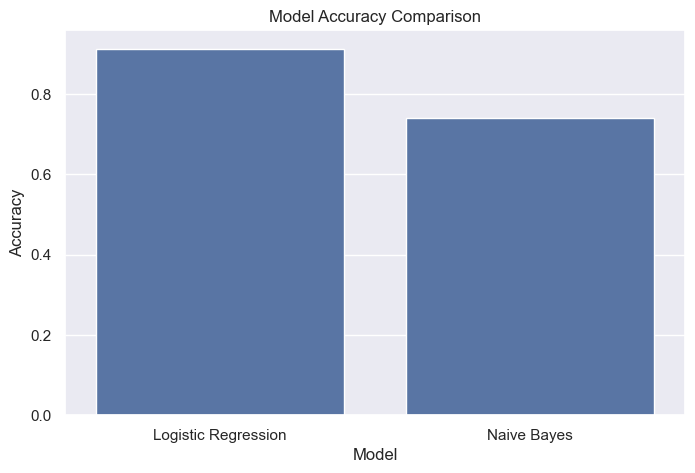

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title("Model Accuracy Comparison")

plt.show()

Visualizations

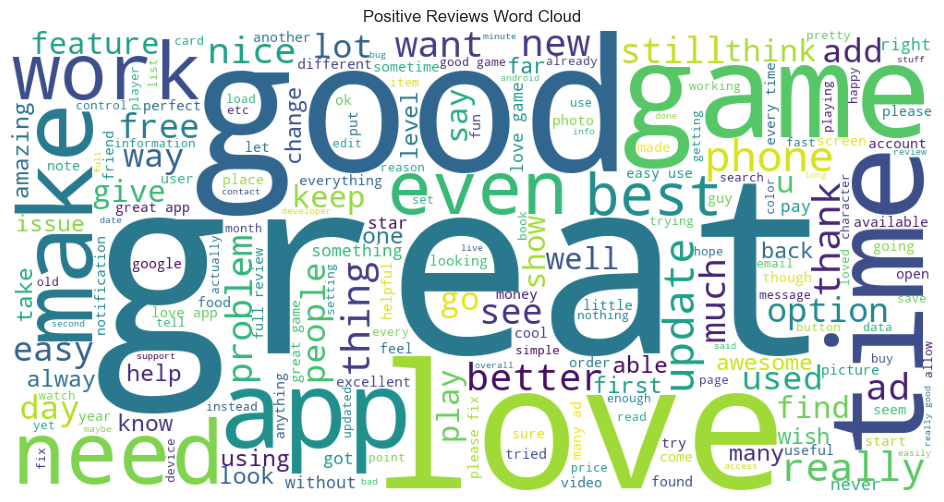

In [32]:
#Positive Word Cloud
positive_text = " ".join(
    df[df['Sentiment']=="Positive"]['clean_review']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Positive Reviews Word Cloud")
plt.show()

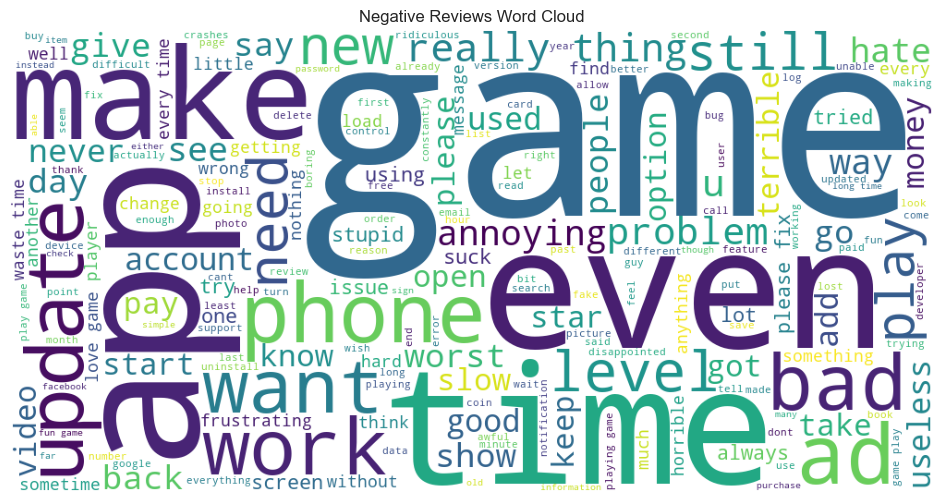

In [33]:
# Negative Word Cloud

negative_text = " ".join(
    df[df['Sentiment']=="Negative"]['clean_review']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

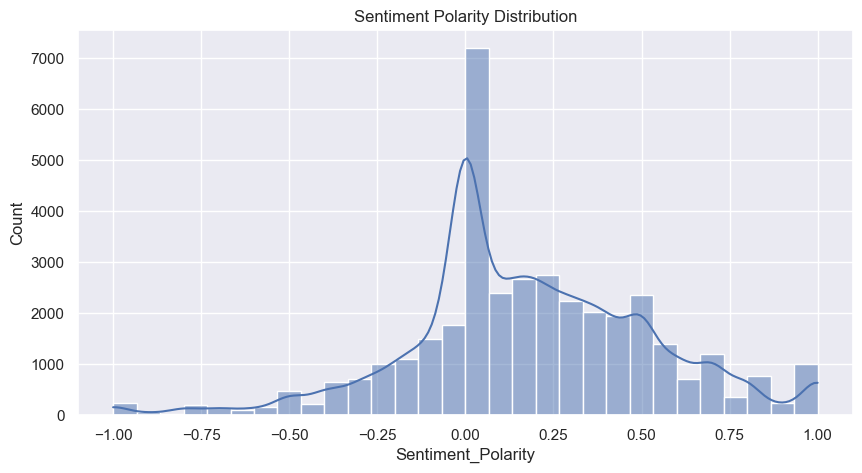

In [34]:
#Sentiment Polarity Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['Sentiment_Polarity'],
    bins=30,
    kde=True
)

plt.title("Sentiment Polarity Distribution")

plt.show()

Top 10 Apps by Review Count

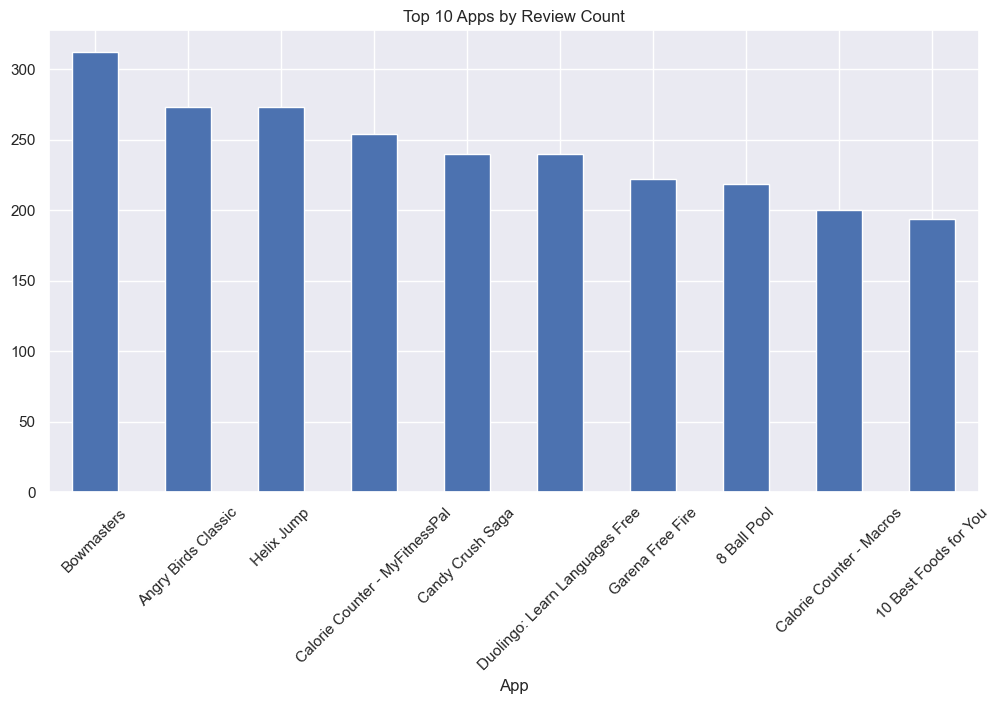

In [35]:
top_apps = df['App'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_apps.plot(kind='bar')

plt.title("Top 10 Apps by Review Count")

plt.xticks(rotation=45)

plt.show()

Confusion Matrix (Best Model)

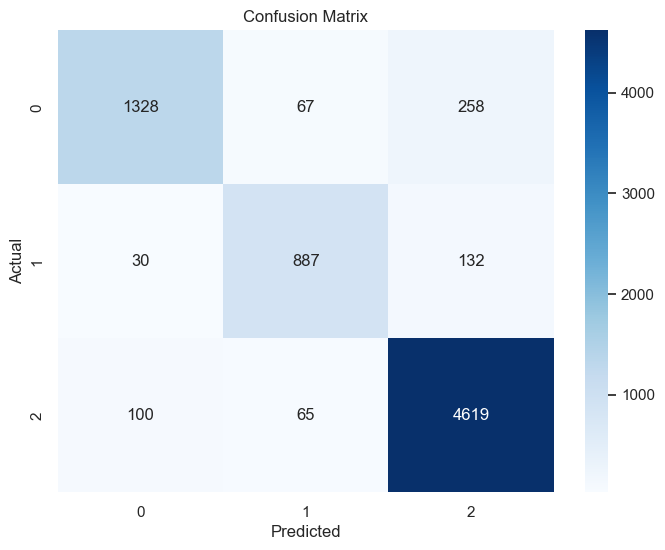

In [36]:
cm = confusion_matrix(
    y_test,
    lr_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Insights

1. Positive reviews account for the majority of user feedback, indicating overall satisfaction with applications.

2. Logistic Regression achieved the highest accuracy (91.29%), making it the most effective model for sentiment classification.

3. Naive Bayes performed reasonably well but was less accurate than Logistic Regression.

4. Word Cloud analysis revealed frequently used positive and negative terms, helping identify user preferences and concerns.

5. Sentiment polarity analysis showed that most reviews have positive sentiment values.

Recommendations

1. Developers should regularly monitor negative reviews to identify recurring issues.

2. Positive feedback can be leveraged to understand features most appreciated by users.

3. Sentiment analysis should be integrated into app review monitoring systems for continuous improvement.

4. Businesses can use sentiment trends to guide product development and customer engagement strategies.

5. Machine learning based sentiment classification can help organizations quickly analyze large volumes of customer feedback.

Conclusion

This project successfully implemented a Sentiment Analysis system using Natural Language Processing and Machine Learning techniques. User reviews from the Google Play Store were preprocessed, transformed using TF-IDF, and classified into Positive, Negative, and Neutral sentiments.

Among the evaluated models, Logistic Regression achieved the highest accuracy of 91.29%, demonstrating its effectiveness in sentiment classification tasks. The project highlights how sentiment analysis can be used to gain valuable insights from customer feedback and support data-driven decision making.